# 问题二新模型：Dynamic Response Transfer Function Model

本 notebook 是第二问的新模型版本，不再沿用之前的“加更多特征”的 enhancement 思路。

之前的 enhanced feature set 效果不稳定，原因是：

```text
1. 特征数量增加，但很多辅助变量边际贡献有限；
2. lag-window 特征维度较高，容易引入噪声；
3. 模型虽然预测提升了一部分，但“不同变量不同时滞参数”的解释不够集中。
```

因此，本 notebook 换成一个更贴合第二问要求的新模型：

```text
Dynamic Response Transfer Function Model
动态响应传递函数模型
```

核心思想：

```text
每个输入变量不是简单取某一个 lag，
也不是把 lag0-lag6 全部塞进模型，
而是为每个变量构造一个“动态响应状态”。
```

动态响应状态定义为：

```text
S_{j,t} = α_j S_{j,t-1} + (1 - α_j) X_{j,t-d_j}
```

其中：

```text
X_{j,t}：第 j 个输入变量
d_j：该变量的纯滞后步数
α_j：该变量的记忆系数 / 衰减系数
S_{j,t}：该变量对 FILT. NTU 的累积动态响应
```

这样每个变量都能得到两个清晰的动态参数：

```text
1. delay d_j：滞后多少个时间步
2. memory α_j：影响持续多久
```

然后建立：

```text
FILT.NTU_t = f(S_R/W_NTU,t, S_R/W_PH,t, S_ALUM,t, S_F/RIDE,t, S_R/W_FLOW,t, FILT.NTU_{t-1}, ...)
```

这个模型比“单一 best lag”更合理，也比“堆很多 lag 特征”更简洁、可解释。


## 1. 导入依赖库

本 notebook 只使用常规机器学习库，不使用 SHAP 和大规模 GridSearch。  
为了兼容旧版 scikit-learn，RMSE 使用：

```python
np.sqrt(mean_squared_error(y_true, y_pred))
```


In [1]:
from pathlib import Path
import warnings
import math
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    XGB_IMPORT_ERROR = e

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

print("XGBoost available:", XGB_AVAILABLE)
if not XGB_AVAILABLE:
    print("XGBoost import error:", XGB_IMPORT_ERROR)


XGBoost available: True


## 2. 参数设置

目标变量：

```text
FILT. NTU
```

核心输入变量：

```text
R/W NTU
R/W PH
ALUM
F/RIDE
R/W FLOW
```

数据每 2 小时记录一次，所以：

```text
delay = 1 代表 2 小时滞后
delay = 3 代表 6 小时滞后
delay = 6 代表 12 小时滞后
```

`memory_alpha` 越大，表示该变量的影响持续越久。


In [2]:
TARGET_COL = "FILT. NTU"
OUTPUT_DIR_NAME = "problem2_dynamic_response"

RANDOM_STATE = 42

# 时间顺序划分：前 60% 用于训练动态参数选择模型，中间 20% 用于验证动态参数，最后 20% 作为最终测试集
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20

RECORD_INTERVAL_HOURS = 2

# 核心变量
CORE_VARS = [
    "R/W NTU",
    "R/W PH",
    "ALUM",
    "F/RIDE",
    "R/W FLOW",
]

# delay grid
DEFAULT_DELAY_GRID = list(range(0, 7))  # 0-12 小时
ALUM_DELAY_GRID = list(range(1, 7))     # ALUM 从 lag1 开始，更符合投药起效滞后

# memory alpha grid
# alpha = 0 表示只看 delay 后的瞬时值；
# alpha 越大，表示历史影响衰减越慢。
MEMORY_ALPHA_GRID = [0.0, 0.25, 0.50, 0.70, 0.85, 0.95]

# 是否加入 FILT. NTU 自回归项
USE_TARGET_AR = True
TARGET_AR_LAGS = [1, 2, 3]

# 是否加入少量物理交互项
USE_INTERACTION_FEATURES = True

# 是否 clipping 目标变量
CLIP_TARGET = False
TARGET_CLIP_UPPER = 2.0

print("参数设置完成。")


参数设置完成。


## 3. 自动定位 `merged.xlsx`

本 notebook 从原始 `merged.xlsx` 读取，独立生成第二题新模型结果，不覆盖旧的 P2 结果。


In [3]:
def locate_merged_file(filename="merged.xlsx"):
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []
    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    for p in cwd.rglob(filename):
        return p.resolve()

    for parent in cwd.parents:
        for p in parent.rglob(filename):
            return p.resolve()

    searched = "\n".join(str(p) for p in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes
使用数据文件： E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
输出目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response


## 4. 读取数据并构造时间列

构造：

```text
DATETIME
OP_DATE
```

`OP_DATE` 使用运行日定义：

```text
07:00 至次日 05:00 归为同一个运行日
```


In [4]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到目标变量 {TARGET_COL}。")


def construct_datetime(data):
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME。")

    date_text = data[date_col].astype(str).str.split().str[0]
    time_text = data[time_col].astype(str).str.split().str[-1]

    data["DATETIME"] = pd.to_datetime(
        date_text + " " + time_text,
        errors="coerce",
    )

    return data


df = construct_datetime(df)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7
df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(12))


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00


,DATETIME,OP_DATE,FILT. NTU
0,2025-01-01 07:00:00,2025-01-01,0.04
1,2025-01-01 09:00:00,2025-01-01,0.05
2,2025-01-01 11:00:00,2025-01-01,0.05
3,2025-01-01 13:00:00,2025-01-01,0.05
4,2025-01-01 15:00:00,2025-01-01,0.05
5,2025-01-01 17:00:00,2025-01-01,0.06
6,2025-01-01 19:00:00,2025-01-01,0.05
7,2025-01-01 21:00:00,2025-01-01,0.05
8,2025-01-01 23:00:00,2025-01-01,0.05
9,2025-01-02 01:00:00,2025-01-01,0.05


## 5. 数据清洗

处理：

```text
1. 核心变量转为 numeric；
2. F/RIDE 缺失填 0；
3. 目标 FILT. NTU 默认不 clipping；
4. 删除目标缺失行。
```


In [5]:
# 数值化所有可用核心列和目标列
for col in [TARGET_COL] + CORE_VARS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# F/RIDE 缺失填 0
if "F/RIDE" in df.columns:
    before_missing = int(df["F/RIDE"].isna().sum())
    df["F/RIDE"] = df["F/RIDE"].fillna(0)
    after_missing = int(df["F/RIDE"].isna().sum())
    print(f"F/RIDE 缺失填 0：before={before_missing}, after={after_missing}")

# target clipping 默认关闭
if CLIP_TARGET:
    before_above = int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum())
    df[TARGET_COL] = df[TARGET_COL].clip(upper=TARGET_CLIP_UPPER)
    after_above = int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum())
    print(f"{TARGET_COL} clipping: before_above={before_above}, after_above={after_above}")
else:
    print("未启用 FILT. NTU clipping。")

available_vars = [v for v in CORE_VARS if v in df.columns]
missing_vars = [v for v in CORE_VARS if v not in df.columns]

print("可用核心变量：", available_vars)
print("缺失核心变量：", missing_vars)

base_cols = ["DATETIME", "OP_DATE", TARGET_COL] + available_vars
base_df = df[base_cols].copy()
base_df = base_df.dropna(subset=["DATETIME", TARGET_COL]).sort_values("DATETIME").reset_index(drop=True)

audit_df = pd.DataFrame({
    "column": base_cols,
    "missing_count": [int(base_df[c].isna().sum()) for c in base_cols],
    "missing_rate": [float(base_df[c].isna().mean()) for c in base_cols],
    "dtype": [str(base_df[c].dtype) for c in base_cols],
})

audit_path = OUTPUT_DIR / "problem2_dynamic_response_data_audit.xlsx"
audit_df.to_excel(audit_path, index=False)

print("建模基础数据规模：", base_df.shape)
print("数据审计表已保存：", audit_path)
display(audit_df)
display(base_df.head())


F/RIDE 缺失填 0：before=0, after=0
未启用 FILT. NTU clipping。
可用核心变量： ['R/W NTU', 'R/W PH', 'ALUM', 'F/RIDE', 'R/W FLOW']
缺失核心变量： []
建模基础数据规模： (5460, 8)
数据审计表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_data_audit.xlsx


,column,missing_count,missing_rate,dtype
0,DATETIME,0,0.000000,datetime64[us]
1,OP_DATE,0,0.000000,object
2,FILT. NTU,0,0.000000,float64
3,R/W NTU,0,0.000000,int64
4,R/W PH,1644,0.301099,float64
5,ALUM,1644,0.301099,float64
6,F/RIDE,0,0.000000,float64
7,R/W FLOW,0,0.000000,float64


,DATETIME,OP_DATE,FILT. NTU,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW
0,2025-01-01 07:00:00,2025-01-01,0.04,150,7.0,0.04,0.0,45.3
1,2025-01-01 09:00:00,2025-01-01,0.05,120,7.0,0.04,0.0,45.2
2,2025-01-01 11:00:00,2025-01-01,0.05,82,7.0,0.04,0.0,44.9
3,2025-01-01 13:00:00,2025-01-01,0.05,62,7.0,0.04,0.0,44.9
4,2025-01-01 15:00:00,2025-01-01,0.05,56,7.0,0.04,0.0,44.5


## 6. 定义动态响应函数

动态响应状态：

```text
S_t = α S_{t-1} + (1 - α) X_{t-d}
```

其中：

```text
d：纯滞后步数
α：记忆系数
```

当：

```text
α = 0
```

表示没有持续记忆，只取 `X_{t-d}`。

当：

```text
α 越接近 1
```

表示该变量影响持续越久。

半衰期近似为：

```text
half_life_hours = log(0.5) / log(α) × 2
```


In [6]:
def safe_name(name):
    return (
        str(name)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(".", "")
        .replace("+", "plus")
        .replace("-", "_")
    )


def dynamic_response(series, delay, memory_alpha):
    """
    构造动态响应状态：
    S_t = alpha * S_{t-1} + (1-alpha) * X_{t-delay}

    使用 pandas ewm 实现。
    """
    x = pd.to_numeric(series, errors="coerce").shift(delay)

    if memory_alpha <= 0:
        return x

    smoothing_alpha = 1.0 - memory_alpha
    z = x.ewm(alpha=smoothing_alpha, adjust=False, ignore_na=True).mean()

    return z


def half_life_hours(memory_alpha, interval_hours=2):
    if memory_alpha <= 0:
        return 0.0
    if memory_alpha >= 1:
        return np.inf
    return float(np.log(0.5) / np.log(memory_alpha) * interval_hours)


def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = np.abs(y_true) > 1e-6
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape,
    }


print("动态响应函数定义完成。")


动态响应函数定义完成。


## 7. 时间顺序划分 train / validation / test

动态响应参数 `delay` 和 `memory_alpha` 在 validation set 上选择。  
最终模型只在 test set 上做最后评价。


In [7]:
n = len(base_df)

train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = base_df.iloc[:train_end].copy()
val_df = base_df.iloc[train_end:val_end].copy()
test_df = base_df.iloc[val_end:].copy()

print("总样本数：", n)
print("训练集：", train_df.shape, train_df["DATETIME"].min(), "至", train_df["DATETIME"].max())
print("验证集：", val_df.shape, val_df["DATETIME"].min(), "至", val_df["DATETIME"].max())
print("测试集：", test_df.shape, test_df["DATETIME"].min(), "至", test_df["DATETIME"].max())


总样本数： 5460
训练集： (3276, 8) 2025-01-01 07:00:00 至 2025-10-01 05:00:00
验证集： (1092, 8) 2025-10-01 07:00:00 至 2025-12-31 05:00:00
测试集： (1092, 8) 2025-12-31 07:00:00 至 2026-04-01 05:00:00


## 8. 为每个输入变量选择动态响应参数

对每个核心变量，遍历：

```text
delay d
memory_alpha α
```

然后用简单 Ridge 模型：

```text
FILT.NTU_t ~ S_{j,t}
```

在训练集上训练，在验证集上计算 RMSE。  
选择验证集 RMSE 最小的 `(d, α)` 作为该变量的动态响应参数。

输出：

```text
problem2_dynamic_response_parameter_search.xlsx
problem2_dynamic_response_selected_parameters.xlsx
```


In [8]:
parameter_search_records = []
selected_parameter_records = []

for var in available_vars:
    print("=" * 80)
    print("Searching dynamic response parameters for:", var)

    if var == "ALUM":
        delay_grid = ALUM_DELAY_GRID
    else:
        delay_grid = DEFAULT_DELAY_GRID

    candidate_records = []

    for delay in delay_grid:
        for memory_alpha in MEMORY_ALPHA_GRID:
            feature_series = dynamic_response(base_df[var], delay=delay, memory_alpha=memory_alpha)

            temp = pd.DataFrame({
                "feature": feature_series,
                "target": base_df[TARGET_COL],
            })

            temp_train = temp.iloc[:train_end].copy()
            temp_val = temp.iloc[train_end:val_end].copy()

            X_train = temp_train[["feature"]]
            y_train = temp_train["target"].values

            X_val = temp_val[["feature"]]
            y_val = temp_val["target"].values

            model = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=1.0)),
            ])

            try:
                model.fit(X_train, y_train)
                y_val_pred = model.predict(X_val)
                metrics = evaluate_regression(y_val, y_val_pred)

                # train correlation，仅用于辅助解释
                train_feature = pd.to_numeric(temp_train["feature"], errors="coerce")
                train_target = pd.to_numeric(temp_train["target"], errors="coerce")
                corr_pearson = train_feature.corr(train_target, method="pearson")
                corr_spearman = train_feature.corr(train_target, method="spearman")

                record = {
                    "variable": var,
                    "delay": delay,
                    "lag_hours": delay * RECORD_INTERVAL_HOURS,
                    "memory_alpha": memory_alpha,
                    "half_life_hours": half_life_hours(memory_alpha, RECORD_INTERVAL_HOURS),
                    "validation_MAE": metrics["MAE"],
                    "validation_RMSE": metrics["RMSE"],
                    "validation_R2": metrics["R2"],
                    "train_pearson_corr": corr_pearson,
                    "train_spearman_corr": corr_spearman,
                }

                candidate_records.append(record)
                parameter_search_records.append(record)

            except Exception as e:
                record = {
                    "variable": var,
                    "delay": delay,
                    "lag_hours": delay * RECORD_INTERVAL_HOURS,
                    "memory_alpha": memory_alpha,
                    "half_life_hours": half_life_hours(memory_alpha, RECORD_INTERVAL_HOURS),
                    "validation_MAE": np.nan,
                    "validation_RMSE": np.nan,
                    "validation_R2": np.nan,
                    "train_pearson_corr": np.nan,
                    "train_spearman_corr": np.nan,
                    "error": str(e),
                }
                candidate_records.append(record)
                parameter_search_records.append(record)

    candidate_df = pd.DataFrame(candidate_records).dropna(subset=["validation_RMSE"])

    if len(candidate_df) == 0:
        print(f"变量 {var} 没有可用动态响应参数。")
        continue

    best_row = candidate_df.sort_values(["validation_RMSE", "validation_MAE"], ascending=[True, True]).iloc[0].to_dict()
    selected_parameter_records.append(best_row)

    print(
        f"Best for {var}: delay={best_row['delay']} "
        f"({best_row['lag_hours']}h), alpha={best_row['memory_alpha']}, "
        f"val_RMSE={best_row['validation_RMSE']:.6f}"
    )

parameter_search_df = pd.DataFrame(parameter_search_records)
selected_params_df = pd.DataFrame(selected_parameter_records)

parameter_search_path = OUTPUT_DIR / "problem2_dynamic_response_parameter_search.xlsx"
selected_params_path = OUTPUT_DIR / "problem2_dynamic_response_selected_parameters.xlsx"

parameter_search_df.to_excel(parameter_search_path, index=False)
selected_params_df.to_excel(selected_params_path, index=False)

print("\n参数搜索表已保存：", parameter_search_path)
print("最优动态响应参数表已保存：", selected_params_path)

display(selected_params_df)


Searching dynamic response parameters for: R/W NTU
Best for R/W NTU: delay=0 (0h), alpha=0.5, val_RMSE=0.421500
Searching dynamic response parameters for: R/W PH
Best for R/W PH: delay=1 (2h), alpha=0.0, val_RMSE=0.459818
Searching dynamic response parameters for: ALUM
Best for ALUM: delay=6 (12h), alpha=0.85, val_RMSE=0.459773
Searching dynamic response parameters for: F/RIDE
Best for F/RIDE: delay=0 (0h), alpha=0.0, val_RMSE=0.459504
Searching dynamic response parameters for: R/W FLOW
Best for R/W FLOW: delay=6 (12h), alpha=0.95, val_RMSE=0.484351

参数搜索表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_parameter_search.xlsx
最优动态响应参数表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_selected_parameters.xlsx


,variable,delay,lag_hours,memory_alpha,half_life_hours,validation_MAE,validation_RMSE,validation_R2,train_pearson_corr,train_spearman_corr
0,R/W NTU,0,0,0.50,2.000000,0.248028,0.421500,0.149796,0.082657,0.112970
1,R/W PH,1,2,0.00,0.000000,0.243816,0.459818,-0.011814,-0.059862,-0.066904
2,ALUM,6,12,0.85,8.530049,0.238550,0.459773,-0.011615,0.016362,0.014180
3,F/RIDE,0,0,0.00,0.000000,0.241628,0.459504,-0.010430,NaN,NaN
4,R/W FLOW,6,12,0.95,27.026815,0.303146,0.484351,-0.122663,0.068365,0.120981


## 9. 构造动态响应建模数据

根据每个变量选出的：

```text
delay d_j
memory_alpha α_j
```

构造最终动态响应特征：

```text
RESP_R/W_NTU
RESP_R/W_PH
RESP_ALUM
RESP_F/RIDE
RESP_R/W_FLOW
```

并可加入：

```text
FILT. NTU_lag1-lag3
```

作为系统自回归惯性项。


In [9]:
model_df = base_df.copy()

response_features = []

for _, row in selected_params_df.iterrows():
    var = row["variable"]
    delay = int(row["delay"])
    memory_alpha = float(row["memory_alpha"])

    feature_name = f"RESP_{safe_name(var)}_d{delay}_a{int(round(memory_alpha * 100))}"

    model_df[feature_name] = dynamic_response(
        model_df[var],
        delay=delay,
        memory_alpha=memory_alpha,
    )

    response_features.append(feature_name)

target_ar_features = []

if USE_TARGET_AR:
    for lag in TARGET_AR_LAGS:
        feature_name = f"{safe_name(TARGET_COL)}_lag{lag}"
        model_df[feature_name] = model_df[TARGET_COL].shift(lag)
        target_ar_features.append(feature_name)

interaction_features = []

if USE_INTERACTION_FEATURES:
    # 只构造少量具有工艺意义的交互项，避免重新变成高维噪声模型。
    def find_resp_feature(original_var):
        prefix = f"RESP_{safe_name(original_var)}_"
        for c in response_features:
            if c.startswith(prefix):
                return c
        return None

    rw_ntu_resp = find_resp_feature("R/W NTU")
    alum_resp = find_resp_feature("ALUM")
    rw_flow_resp = find_resp_feature("R/W FLOW")
    rw_ph_resp = find_resp_feature("R/W PH")

    if rw_ntu_resp is not None and alum_resp is not None:
        c = "INTERACT_RESP_RW_NTU_x_ALUM"
        model_df[c] = model_df[rw_ntu_resp] * model_df[alum_resp]
        interaction_features.append(c)

    if rw_ntu_resp is not None and rw_flow_resp is not None:
        c = "INTERACT_RESP_RW_NTU_x_RW_FLOW"
        model_df[c] = model_df[rw_ntu_resp] * model_df[rw_flow_resp]
        interaction_features.append(c)

    if alum_resp is not None and rw_ph_resp is not None:
        c = "INTERACT_RESP_ALUM_x_RW_PH"
        model_df[c] = model_df[alum_resp] * model_df[rw_ph_resp]
        interaction_features.append(c)

feature_sets = {
    "ResponseOnly": response_features,
    "ResponseARX": response_features + target_ar_features,
}

if USE_INTERACTION_FEATURES and len(interaction_features) > 0:
    feature_sets["ResponseARX_Interaction"] = response_features + target_ar_features + interaction_features

all_model_features = list(dict.fromkeys(
    response_features + target_ar_features + interaction_features
))

model_data = model_df[["DATETIME", "OP_DATE", TARGET_COL] + all_model_features].copy()
model_data = model_data.rename(columns={TARGET_COL: "target_FILT_NTU"})
model_data = model_data.dropna(subset=["target_FILT_NTU", "DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

model_data_path = OUTPUT_DIR / "problem2_dynamic_response_model_data.xlsx"
model_data.to_excel(model_data_path, index=False)

feature_description_records = []

for feature in response_features:
    feature_description_records.append({
        "feature": feature,
        "feature_type": "dynamic_response_state",
        "description": "Selected transfer-function response state for a core input variable.",
    })

for feature in target_ar_features:
    feature_description_records.append({
        "feature": feature,
        "feature_type": "target_autoregressive_lag",
        "description": "Past FILT. NTU value used to capture system inertia.",
    })

for feature in interaction_features:
    feature_description_records.append({
        "feature": feature,
        "feature_type": "process_interaction",
        "description": "Low-dimensional process interaction term.",
    })

feature_description_df = pd.DataFrame(feature_description_records)
feature_description_path = OUTPUT_DIR / "problem2_dynamic_response_feature_description.xlsx"
feature_description_df.to_excel(feature_description_path, index=False)

print("Response features:", response_features)
print("Target AR features:", target_ar_features)
print("Interaction features:", interaction_features)
print("建模数据已保存：", model_data_path)
print("特征说明已保存：", feature_description_path)
display(feature_description_df)
display(model_data.head())


Response features: ['RESP_R_W_NTU_d0_a50', 'RESP_R_W_PH_d1_a0', 'RESP_ALUM_d6_a85', 'RESP_F_RIDE_d0_a0', 'RESP_R_W_FLOW_d6_a95']
Target AR features: ['FILT_NTU_lag1', 'FILT_NTU_lag2', 'FILT_NTU_lag3']
Interaction features: ['INTERACT_RESP_RW_NTU_x_ALUM', 'INTERACT_RESP_RW_NTU_x_RW_FLOW', 'INTERACT_RESP_ALUM_x_RW_PH']
建模数据已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_model_data.xlsx
特征说明已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_feature_description.xlsx


,feature,feature_type,description
0,RESP_R_W_NTU_d0_a50,dynamic_response_state,Selected transfer-function response state for ...
1,RESP_R_W_PH_d1_a0,dynamic_response_state,Selected transfer-function response state for ...
2,RESP_ALUM_d6_a85,dynamic_response_state,Selected transfer-function response state for ...
3,RESP_F_RIDE_d0_a0,dynamic_response_state,Selected transfer-function response state for ...
4,RESP_R_W_FLOW_d6_a95,dynamic_response_state,Selected transfer-function response state for ...
5,FILT_NTU_lag1,target_autoregressive_lag,Past FILT. NTU value used to capture system in...
6,FILT_NTU_lag2,target_autoregressive_lag,Past FILT. NTU value used to capture system in...
7,FILT_NTU_lag3,target_autoregressive_lag,Past FILT. NTU value used to capture system in...
8,INTERACT_RESP_RW_NTU_x_ALUM,process_interaction,Low-dimensional process interaction term.
9,INTERACT_RESP_RW_NTU_x_RW_FLOW,process_interaction,Low-dimensional process interaction term.


,DATETIME,OP_DATE,target_FILT_NTU,RESP_R_W_NTU_d0_a50,RESP_R_W_PH_d1_a0,RESP_ALUM_d6_a85,RESP_F_RIDE_d0_a0,RESP_R_W_FLOW_d6_a95,FILT_NTU_lag1,FILT_NTU_lag2,FILT_NTU_lag3,INTERACT_RESP_RW_NTU_x_ALUM,INTERACT_RESP_RW_NTU_x_RW_FLOW,INTERACT_RESP_ALUM_x_RW_PH
0,2025-01-01 07:00:00,2025-01-01,0.04,150.000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 09:00:00,2025-01-01,0.05,135.000,7.0,NaN,0.0,NaN,0.04,NaN,NaN,NaN,NaN,NaN
2,2025-01-01 11:00:00,2025-01-01,0.05,108.500,7.0,NaN,0.0,NaN,0.05,0.04,NaN,NaN,NaN,NaN
3,2025-01-01 13:00:00,2025-01-01,0.05,85.250,7.0,NaN,0.0,NaN,0.05,0.05,0.04,NaN,NaN,NaN
4,2025-01-01 15:00:00,2025-01-01,0.05,70.625,7.0,NaN,0.0,NaN,0.05,0.05,0.05,NaN,NaN,NaN


## 10. 最终时间顺序训练 / 测试划分

动态参数已经在 validation set 上选定。  
最终模型使用：

```text
train + validation
```

训练，并在最后 20% test set 上评价。


In [10]:
n_model = len(model_data)

# 由于 model_data 删除了少量前置缺失行，这里重新按照比例划分。
final_train_end = int(n_model * (TRAIN_RATIO + VAL_RATIO))

final_train_df = model_data.iloc[:final_train_end].copy()
final_test_df = model_data.iloc[final_train_end:].copy()

print("最终建模数据样本数：", n_model)
print("最终训练集：", final_train_df.shape, final_train_df["DATETIME"].min(), "至", final_train_df["DATETIME"].max())
print("最终测试集：", final_test_df.shape, final_test_df["DATETIME"].min(), "至", final_test_df["DATETIME"].max())

y_train = final_train_df["target_FILT_NTU"].values
y_test = final_test_df["target_FILT_NTU"].values

for fs_name, cols in feature_sets.items():
    print(fs_name, "feature_count =", len(cols))


最终建模数据样本数： 5460
最终训练集： (4368, 14) 2025-01-01 07:00:00 至 2025-12-31 05:00:00
最终测试集： (1092, 14) 2025-12-31 07:00:00 至 2026-04-01 05:00:00
ResponseOnly feature_count = 5
ResponseARX feature_count = 8
ResponseARX_Interaction feature_count = 11


## 11. 定义最终模型

这里训练：

```text
Dynamic Response Ridge
Dynamic Response ElasticNet
Dynamic Response GAM
Dynamic Response Random Forest
Dynamic Response XGBoost
```

最终以 test RMSE 和 R² 选择模型。


In [11]:
def build_models():
    models = {}

    models["Ridge"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ])

    models["ElasticNet"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=RANDOM_STATE, max_iter=20000)),
    ])

    models["GAM"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False)),
        ("model", Ridge(alpha=10.0)),
    ])

    models["Random Forest"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            max_features="sqrt",
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ])

    if XGB_AVAILABLE:
        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=3,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])

    return models


print("最终模型定义完成。")


最终模型定义完成。


## 12. 训练最终模型并输出结果

输出：

```text
problem2_dynamic_response_model_results.xlsx
problem2_dynamic_response_test_predictions.xlsx
models/*.joblib
```


In [12]:
results_records = []
prediction_frames = []
trained_models = {}

for feature_set_name, feature_cols in feature_sets.items():
    print("=" * 80)
    print(f"Feature set: {feature_set_name}, feature_count={len(feature_cols)}")
    print("=" * 80)

    X_train = final_train_df[feature_cols].copy()
    X_test = final_test_df[feature_cols].copy()

    models = build_models()

    for model_name, model in models.items():
        print(f"Training {feature_set_name} - {model_name} ...")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_regression(y_test, y_pred)

        result = {
            "feature_set": feature_set_name,
            "model": model_name,
            "n_features": len(feature_cols),
            "train_samples": len(X_train),
            "test_samples": len(X_test),
            **metrics,
        }

        results_records.append(result)

        pred_df = final_test_df[["DATETIME", "OP_DATE", "target_FILT_NTU"]].copy()
        pred_df["feature_set"] = feature_set_name
        pred_df["model"] = model_name
        pred_df["predicted_FILT_NTU"] = y_pred
        pred_df["residual"] = pred_df["target_FILT_NTU"] - pred_df["predicted_FILT_NTU"]
        prediction_frames.append(pred_df)

        key = f"{feature_set_name}__{model_name}"
        trained_models[key] = {
            "model": model,
            "features": feature_cols,
            "metrics": metrics,
        }

        model_path = MODEL_DIR / f"p2_dynamic_response_{feature_set_name}_{model_name}.joblib".replace(" ", "_")
        joblib.dump({
            "model": model,
            "feature_cols": feature_cols,
            "target_col": "target_FILT_NTU",
            "feature_set": feature_set_name,
            "model_name": model_name,
            "metrics": metrics,
        }, model_path)

        print(f"  MAE={metrics['MAE']:.6f}, RMSE={metrics['RMSE']:.6f}, R2={metrics['R2']:.6f}")

results_df = pd.DataFrame(results_records).sort_values(["RMSE", "MAE"], ascending=[True, True]).reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

results_path = OUTPUT_DIR / "problem2_dynamic_response_model_results.xlsx"
predictions_path = OUTPUT_DIR / "problem2_dynamic_response_test_predictions.xlsx"

results_df.to_excel(results_path, index=False)
predictions_df.to_excel(predictions_path, index=False)

print("模型结果已保存：", results_path)
print("测试集预测已保存：", predictions_path)

display(results_df)


Feature set: ResponseOnly, feature_count=5
Training ResponseOnly - Ridge ...
  MAE=0.168427, RMSE=0.253854, R2=-0.348569
Training ResponseOnly - ElasticNet ...
  MAE=0.163378, RMSE=0.250045, R2=-0.308403
Training ResponseOnly - GAM ...
  MAE=0.160421, RMSE=0.247030, R2=-0.277041
Training ResponseOnly - Random Forest ...
  MAE=0.285321, RMSE=0.464113, R2=-3.507673
Training ResponseOnly - XGBoost ...
  MAE=0.250225, RMSE=0.378592, R2=-1.999486
Feature set: ResponseARX, feature_count=8
Training ResponseARX - Ridge ...
  MAE=0.045249, RMSE=0.173574, R2=0.369519
Training ResponseARX - ElasticNet ...
  MAE=0.044515, RMSE=0.173385, R2=0.370888
Training ResponseARX - GAM ...
  MAE=0.065687, RMSE=0.203096, R2=0.136806
Training ResponseARX - Random Forest ...
  MAE=0.048971, RMSE=0.194530, R2=0.208088
Training ResponseARX - XGBoost ...
  MAE=0.044536, RMSE=0.190713, R2=0.238858
Feature set: ResponseARX_Interaction, feature_count=11
Training ResponseARX_Interaction - Ridge ...
  MAE=0.047855, RMS

,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,ResponseARX,ElasticNet,8,4368,1092,0.044515,0.173385,0.370888,37.769149
1,ResponseARX_Interaction,ElasticNet,11,4368,1092,0.045905,0.173486,0.370157,40.362935
2,ResponseARX,Ridge,8,4368,1092,0.045249,0.173574,0.369519,39.031644
3,ResponseARX_Interaction,Ridge,11,4368,1092,0.047855,0.173809,0.367806,44.045289
4,ResponseARX_Interaction,XGBoost,11,4368,1092,0.044191,0.189865,0.245611,30.106896
5,ResponseARX,XGBoost,8,4368,1092,0.044536,0.190713,0.238858,30.330814
6,ResponseARX,Random Forest,8,4368,1092,0.048971,0.194530,0.208088,35.365648
7,ResponseARX_Interaction,Random Forest,11,4368,1092,0.050741,0.201385,0.151290,37.525876
8,ResponseARX,GAM,8,4368,1092,0.065687,0.203096,0.136806,64.851757
9,ResponseARX_Interaction,GAM,11,4368,1092,0.065203,0.203493,0.133430,62.266275


## 13. 与旧 P2 结果和 enhanced P2 结果对比

如果存在旧结果文件，会自动读取对比。  
这一步用于判断新模型是否比前面的 selected-lag 或 enhanced feature model 更有价值。


In [13]:
compare_frames = []

# 当前新模型
current_compare = results_df.copy()
current_compare["version"] = "P2_dynamic_response_transfer_function"
compare_frames.append(current_compare)

# 尝试读取原始 P2
old_candidates = [
    PROJECT_DIR / "outputs" / "problem2" / "problem2_model_results.xlsx",
    PROJECT_DIR / "outputs" / "problem2" / "problem2_correct_dynamic_model_results.xlsx",
]

for p in old_candidates:
    if p.exists():
        old_df = pd.read_excel(p)
        if "feature_set" not in old_df.columns:
            old_df["feature_set"] = "Selected_one_lag"
        old_df["version"] = "P2_original_selected_lag"
        compare_frames.append(old_df)
        print("已读取旧版 P2：", p)
        break

# 尝试读取 enhanced P2
enhanced_candidates = [
    PROJECT_DIR / "outputs" / "problem2_enhanced" / "problem2_enhanced_model_results.xlsx",
]

for p in enhanced_candidates:
    if p.exists():
        enh_df = pd.read_excel(p)
        enh_df["version"] = "P2_enhanced_feature_model"
        compare_frames.append(enh_df)
        print("已读取 enhanced P2：", p)
        break

common_cols = ["version", "feature_set", "model", "n_features", "MAE", "RMSE", "R2", "MAPE_percent"]
comparison_df = pd.concat(
    [df_.reindex(columns=common_cols) for df_ in compare_frames],
    ignore_index=True,
)

comparison_df = comparison_df.sort_values("RMSE", ascending=True).reset_index(drop=True)

comparison_path = OUTPUT_DIR / "problem2_dynamic_response_comparison_with_previous.xlsx"
comparison_df.to_excel(comparison_path, index=False)

print("模型对比表已保存：", comparison_path)
display(comparison_df)


已读取旧版 P2： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2\problem2_model_results.xlsx
已读取 enhanced P2： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_enhanced\problem2_enhanced_model_results.xlsx
模型对比表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_comparison_with_previous.xlsx


,version,feature_set,model,n_features,MAE,RMSE,R2,MAPE_percent
0,P2_dynamic_response_transfer_function,ResponseARX,ElasticNet,8,0.044515,0.173385,0.370888,37.769149
1,P2_dynamic_response_transfer_function,ResponseARX_Interaction,ElasticNet,11,0.045905,0.173486,0.370157,40.362935
2,P2_dynamic_response_transfer_function,ResponseARX,Ridge,8,0.045249,0.173574,0.369519,39.031644
3,P2_dynamic_response_transfer_function,ResponseARX_Interaction,Ridge,11,0.047855,0.173809,0.367806,44.045289
4,P2_dynamic_response_transfer_function,ResponseARX_Interaction,XGBoost,11,0.044191,0.189865,0.245611,30.106896
5,P2_dynamic_response_transfer_function,ResponseARX,XGBoost,8,0.044536,0.190713,0.238858,30.330814
6,P2_dynamic_response_transfer_function,ResponseARX,Random Forest,8,0.048971,0.194530,0.208088,35.365648
7,P2_dynamic_response_transfer_function,ResponseARX_Interaction,Random Forest,11,0.050741,0.201385,0.151290,37.525876
8,P2_dynamic_response_transfer_function,ResponseARX,GAM,8,0.065687,0.203096,0.136806,64.851757
9,P2_dynamic_response_transfer_function,ResponseARX_Interaction,GAM,11,0.065203,0.203493,0.133430,62.266275


## 14. 提取 Ridge / ElasticNet 参数

这部分用于论文解释变量方向和动态响应强度。

输出：

```text
problem2_dynamic_response_linear_coefficients.xlsx
```


In [14]:
coef_records = []

for key, item in trained_models.items():
    feature_set_name, model_name = key.split("__", 1)

    if model_name not in ["Ridge", "ElasticNet"]:
        continue

    model = item["model"]
    feature_cols = item["features"]

    estimator = model.named_steps["model"]

    coef_df = pd.DataFrame({
        "feature_set": feature_set_name,
        "model": model_name,
        "feature": feature_cols,
        "coefficient": estimator.coef_,
    })

    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
    coef_records.append(coef_df)

coef_df = pd.concat(coef_records, ignore_index=True) if coef_records else pd.DataFrame()

coef_path = OUTPUT_DIR / "problem2_dynamic_response_linear_coefficients.xlsx"
coef_df.to_excel(coef_path, index=False)

print("线性模型参数表已保存：", coef_path)
display(coef_df.head(40))


线性模型参数表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_linear_coefficients.xlsx


,feature_set,model,feature,coefficient,abs_coefficient
0,ResponseOnly,Ridge,RESP_R_W_NTU_d0_a50,0.119022,0.119022
1,ResponseOnly,Ridge,RESP_ALUM_d6_a85,0.037833,0.037833
2,ResponseOnly,Ridge,RESP_R_W_FLOW_d6_a95,0.021438,0.021438
3,ResponseOnly,Ridge,RESP_F_RIDE_d0_a0,-0.011407,0.011407
4,ResponseOnly,Ridge,RESP_R_W_PH_d1_a0,-0.006426,0.006426
5,ResponseOnly,ElasticNet,RESP_R_W_NTU_d0_a50,0.114613,0.114613
6,ResponseOnly,ElasticNet,RESP_ALUM_d6_a85,0.033544,0.033544
7,ResponseOnly,ElasticNet,RESP_R_W_FLOW_d6_a95,0.017638,0.017638
8,ResponseOnly,ElasticNet,RESP_F_RIDE_d0_a0,-0.009103,0.009103
9,ResponseOnly,ElasticNet,RESP_R_W_PH_d1_a0,-0.004873,0.004873


## 15. 树模型特征重要性

输出：

```text
problem2_dynamic_response_feature_importance.xlsx
```


In [15]:
importance_records = []

for key, item in trained_models.items():
    feature_set_name, model_name = key.split("__", 1)

    if model_name not in ["Random Forest", "XGBoost"]:
        continue

    model = item["model"]
    feature_cols = item["features"]
    estimator = model.named_steps["model"]

    if hasattr(estimator, "feature_importances_"):
        imp = estimator.feature_importances_
    else:
        continue

    temp = pd.DataFrame({
        "feature_set": feature_set_name,
        "model": model_name,
        "feature": feature_cols,
        "importance": imp,
    }).sort_values("importance", ascending=False)

    temp["rank"] = np.arange(1, len(temp) + 1)
    importance_records.append(temp)

importance_df = pd.concat(importance_records, ignore_index=True) if importance_records else pd.DataFrame()

importance_path = OUTPUT_DIR / "problem2_dynamic_response_feature_importance.xlsx"
importance_df.to_excel(importance_path, index=False)

print("特征重要性表已保存：", importance_path)
display(importance_df.head(40))


特征重要性表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_feature_importance.xlsx


,feature_set,model,feature,importance,rank
0,ResponseOnly,Random Forest,RESP_R_W_FLOW_d6_a95,0.394052,1
1,ResponseOnly,Random Forest,RESP_R_W_NTU_d0_a50,0.320621,2
2,ResponseOnly,Random Forest,RESP_ALUM_d6_a85,0.242297,3
3,ResponseOnly,Random Forest,RESP_F_RIDE_d0_a0,0.035841,4
4,ResponseOnly,Random Forest,RESP_R_W_PH_d1_a0,0.007189,5
5,ResponseOnly,XGBoost,RESP_F_RIDE_d0_a0,0.421537,1
6,ResponseOnly,XGBoost,RESP_ALUM_d6_a85,0.207659,2
7,ResponseOnly,XGBoost,RESP_R_W_NTU_d0_a50,0.179825,3
8,ResponseOnly,XGBoost,RESP_R_W_FLOW_d6_a95,0.166493,4
9,ResponseOnly,XGBoost,RESP_R_W_PH_d1_a0,0.024486,5


## 16. 可视化：模型性能对比

输出：

```text
figures/problem2_dynamic_response_rmse_comparison.png
figures/problem2_dynamic_response_r2_comparison.png
```


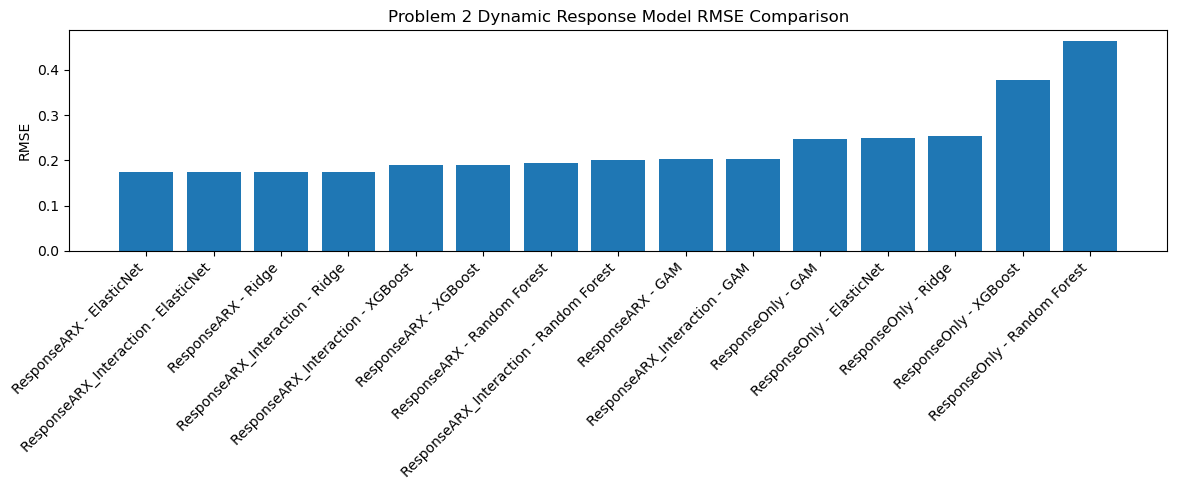

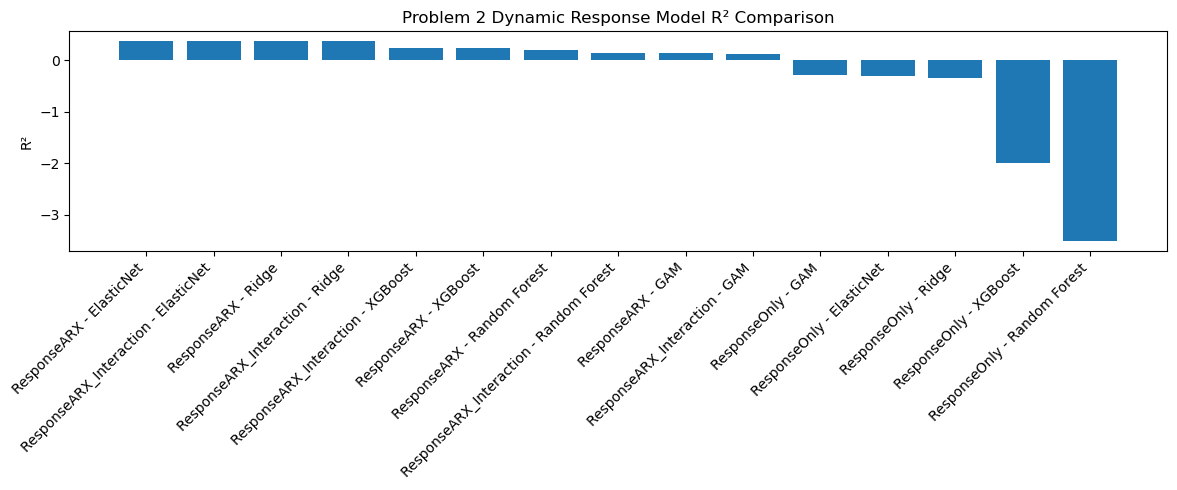

RMSE 图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\figures\problem2_dynamic_response_rmse_comparison.png
R² 图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\figures\problem2_dynamic_response_r2_comparison.png


In [16]:
plot_df = results_df.copy()
plot_df["label"] = plot_df["feature_set"] + " - " + plot_df["model"]

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Problem 2 Dynamic Response Model RMSE Comparison")
plt.tight_layout()

rmse_fig_path = FIG_DIR / "problem2_dynamic_response_rmse_comparison.png"
plt.savefig(rmse_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Problem 2 Dynamic Response Model R² Comparison")
plt.tight_layout()

r2_fig_path = FIG_DIR / "problem2_dynamic_response_r2_comparison.png"
plt.savefig(r2_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("RMSE 图已保存：", rmse_fig_path)
print("R² 图已保存：", r2_fig_path)


## 17. 可视化：最佳模型预测曲线、散点图和残差图

根据 RMSE 自动选择最佳模型。


最佳模型：


,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,ResponseARX,ElasticNet,8,4368,1092,0.044515,0.173385,0.370888,37.769149


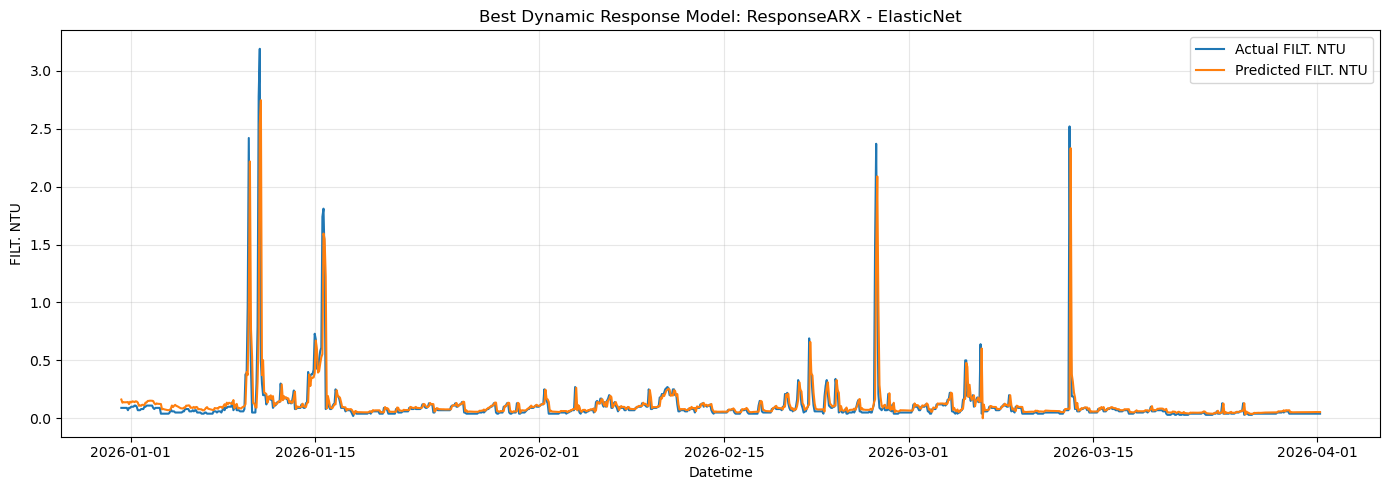

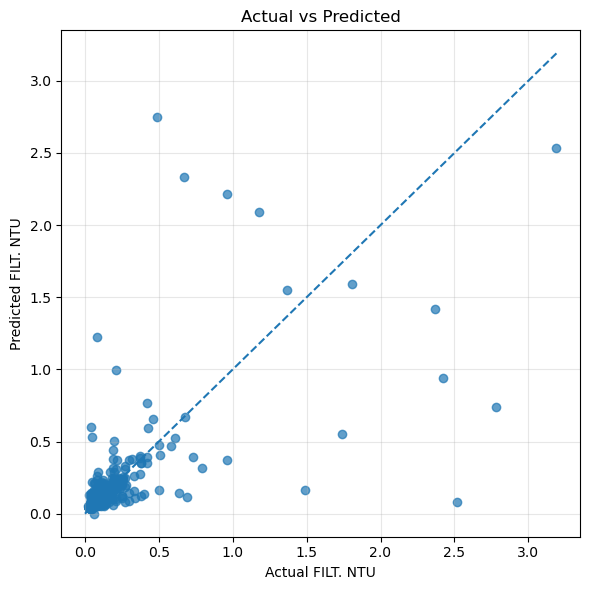

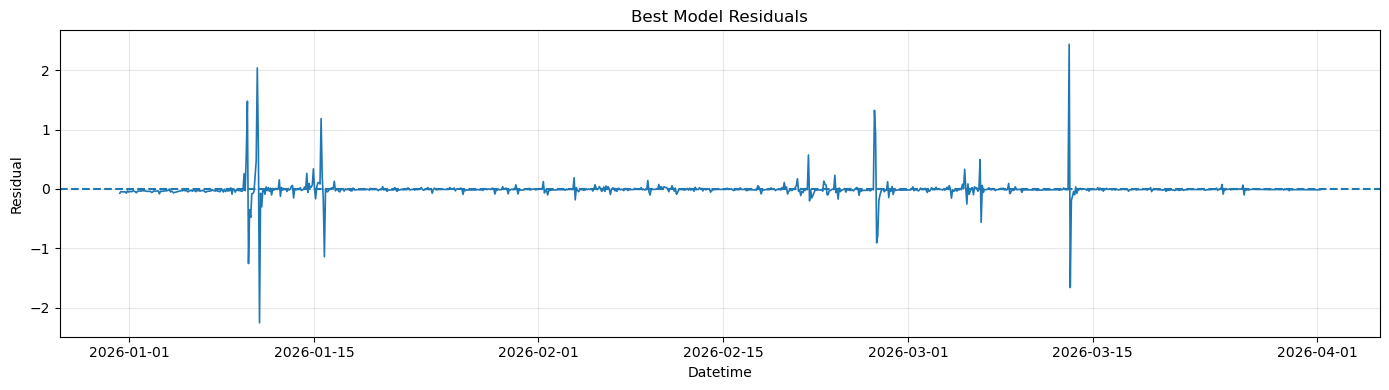

最佳模型预测曲线已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\figures\problem2_dynamic_response_best_model_timeseries.png
实际-预测散点图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\figures\problem2_dynamic_response_actual_vs_predicted.png
残差图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\figures\problem2_dynamic_response_residuals.png


In [17]:
best_row = results_df.iloc[0]
best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]

best_pred_df = predictions_df[
    (predictions_df["feature_set"] == best_feature_set) &
    (predictions_df["model"] == best_model_name)
].copy()

print("最佳模型：")
display(best_row.to_frame().T)

plt.figure(figsize=(14, 5))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["target_FILT_NTU"],
    label="Actual FILT. NTU",
    linewidth=1.5,
)
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["predicted_FILT_NTU"],
    label="Predicted FILT. NTU",
    linewidth=1.5,
)
plt.title(f"Best Dynamic Response Model: {best_feature_set} - {best_model_name}")
plt.xlabel("Datetime")
plt.ylabel("FILT. NTU")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

best_ts_fig_path = FIG_DIR / "problem2_dynamic_response_best_model_timeseries.png"
plt.savefig(best_ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(
    best_pred_df["target_FILT_NTU"],
    best_pred_df["predicted_FILT_NTU"],
    alpha=0.7,
)
min_val = min(best_pred_df["target_FILT_NTU"].min(), best_pred_df["predicted_FILT_NTU"].min())
max_val = max(best_pred_df["target_FILT_NTU"].max(), best_pred_df["predicted_FILT_NTU"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual FILT. NTU")
plt.ylabel("Predicted FILT. NTU")
plt.title("Actual vs Predicted")
plt.grid(alpha=0.3)
plt.tight_layout()

avp_fig_path = FIG_DIR / "problem2_dynamic_response_actual_vs_predicted.png"
plt.savefig(avp_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["residual"],
    linewidth=1.2,
)
plt.axhline(0, linestyle="--")
plt.title("Best Model Residuals")
plt.xlabel("Datetime")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.tight_layout()

residual_fig_path = FIG_DIR / "problem2_dynamic_response_residuals.png"
plt.savefig(residual_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("最佳模型预测曲线已保存：", best_ts_fig_path)
print("实际-预测散点图已保存：", avp_fig_path)
print("残差图已保存：", residual_fig_path)


## 18. 输出最终摘要

输出：

```text
problem2_dynamic_response_final_summary.xlsx
```

这个表可以直接交给论文手。


In [18]:
final_summary = pd.DataFrame([
    {
        "item": "model_name",
        "value": "Dynamic Response Transfer Function Model",
    },
    {
        "item": "target",
        "value": "FILT. NTU",
    },
    {
        "item": "best_feature_set",
        "value": best_feature_set,
    },
    {
        "item": "best_model",
        "value": best_model_name,
    },
    {
        "item": "best_MAE",
        "value": best_row["MAE"],
    },
    {
        "item": "best_RMSE",
        "value": best_row["RMSE"],
    },
    {
        "item": "best_R2",
        "value": best_row["R2"],
    },
    {
        "item": "main_advantage_1",
        "value": "Each input variable has explicit delay and memory parameters.",
    },
    {
        "item": "main_advantage_2",
        "value": "Avoids high-dimensional lag-window feature stacking.",
    },
    {
        "item": "main_advantage_3",
        "value": "More directly matches the requirement of variable-specific dynamic lag parameters.",
    },
])

final_summary_path = OUTPUT_DIR / "problem2_dynamic_response_final_summary.xlsx"
final_summary.to_excel(final_summary_path, index=False)

print("最终摘要已保存：", final_summary_path)
display(final_summary)


最终摘要已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_final_summary.xlsx


,item,value
0,model_name,Dynamic Response Transfer Function Model
1,target,FILT. NTU
2,best_feature_set,ResponseARX
3,best_model,ElasticNet
4,best_MAE,0.044515
5,best_RMSE,0.173385
6,best_R2,0.370888
7,main_advantage_1,Each input variable has explicit delay and mem...
8,main_advantage_2,Avoids high-dimensional lag-window feature sta...
9,main_advantage_3,More directly matches the requirement of varia...


## 19. 论文中可使用的表述

中文表述：

```text
为避免简单堆叠多滞后特征造成的高维噪声，本文进一步构建动态响应传递函数模型。该模型对每个输入变量分别估计纯滞后参数 d_j 和记忆衰减参数 α_j，将原始输入变量转化为动态响应状态 S_{j,t}=α_j S_{j,t-1}+(1-α_j)X_{j,t-d_j}。其中 d_j 表示变量影响开始作用的时间滞后，α_j 表示影响持续性。随后，以各变量动态响应状态和 FILT. NTU 自回归项作为输入，建立滤后水浊度动态预测模型。该方法既保留了动态时滞解释能力，又避免了传统多滞后窗口模型的特征冗余问题。
```

英文表述：

```text
To avoid the high-dimensional noise caused by stacking multiple lagged features, a dynamic response transfer function model was further developed. For each input variable, a pure delay parameter d_j and a memory decay parameter α_j were estimated, and the original input was transformed into a dynamic response state S_{j,t}=α_j S_{j,t-1}+(1-α_j)X_{j,t-d_j}. Here, d_j represents the response delay, while α_j characterizes the persistence of the variable effect. The dynamic response states, together with autoregressive FILT. NTU terms, were then used to model the filtered water turbidity. This approach provides explicit variable-specific lag parameters while reducing feature redundancy.
```


In [19]:
print("=" * 80)
print("问题二新模型 Dynamic Response Transfer Function Model 已完成。")
print("=" * 80)

print("\n核心输出文件：")
print("1. 数据审计：", audit_path)
print("2. 参数搜索：", parameter_search_path)
print("3. 选定动态参数：", selected_params_path)
print("4. 特征说明：", feature_description_path)
print("5. 建模数据：", model_data_path)
print("6. 模型结果：", results_path)
print("7. 测试集预测：", predictions_path)
print("8. 对比旧模型：", comparison_path)
print("9. 线性系数：", coef_path)
print("10. 特征重要性：", importance_path)
print("11. 最终摘要：", final_summary_path)
print("12. 图片目录：", FIG_DIR)

print("\n选定动态响应参数：")
display(selected_params_df)

print("\n模型结果：")
display(results_df)

print("\n最佳模型：")
display(best_row.to_frame().T)


问题二新模型 Dynamic Response Transfer Function Model 已完成。

核心输出文件：
1. 数据审计： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_data_audit.xlsx
2. 参数搜索： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_parameter_search.xlsx
3. 选定动态参数： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_selected_parameters.xlsx
4. 特征说明： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_feature_description.xlsx
5. 建模数据： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_model_data.xlsx
6. 模型结果： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_model_results.xlsx
7. 测试集预测： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem2_dynamic_response_test_predictions.xlsx
8. 对比旧模型： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_dynamic_response\problem

,variable,delay,lag_hours,memory_alpha,half_life_hours,validation_MAE,validation_RMSE,validation_R2,train_pearson_corr,train_spearman_corr
0,R/W NTU,0,0,0.50,2.000000,0.248028,0.421500,0.149796,0.082657,0.112970
1,R/W PH,1,2,0.00,0.000000,0.243816,0.459818,-0.011814,-0.059862,-0.066904
2,ALUM,6,12,0.85,8.530049,0.238550,0.459773,-0.011615,0.016362,0.014180
3,F/RIDE,0,0,0.00,0.000000,0.241628,0.459504,-0.010430,NaN,NaN
4,R/W FLOW,6,12,0.95,27.026815,0.303146,0.484351,-0.122663,0.068365,0.120981



模型结果：


,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,ResponseARX,ElasticNet,8,4368,1092,0.044515,0.173385,0.370888,37.769149
1,ResponseARX_Interaction,ElasticNet,11,4368,1092,0.045905,0.173486,0.370157,40.362935
2,ResponseARX,Ridge,8,4368,1092,0.045249,0.173574,0.369519,39.031644
3,ResponseARX_Interaction,Ridge,11,4368,1092,0.047855,0.173809,0.367806,44.045289
4,ResponseARX_Interaction,XGBoost,11,4368,1092,0.044191,0.189865,0.245611,30.106896
5,ResponseARX,XGBoost,8,4368,1092,0.044536,0.190713,0.238858,30.330814
6,ResponseARX,Random Forest,8,4368,1092,0.048971,0.194530,0.208088,35.365648
7,ResponseARX_Interaction,Random Forest,11,4368,1092,0.050741,0.201385,0.151290,37.525876
8,ResponseARX,GAM,8,4368,1092,0.065687,0.203096,0.136806,64.851757
9,ResponseARX_Interaction,GAM,11,4368,1092,0.065203,0.203493,0.133430,62.266275



最佳模型：


,feature_set,model,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,ResponseARX,ElasticNet,8,4368,1092,0.044515,0.173385,0.370888,37.769149
